In [3]:

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")
print("Student ID: cit-24-01-0458")
print("Model: Support Vector Machine (SVM)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Student ID: cit-24-01-0458
Model: Support Vector Machine (SVM)


In [2]:
import os

# Check folders inside Google Drive
print("My Drive folders:")
print(os.listdir("/content/drive/MyDrive"))

My Drive folders:
['NLP_Fake_News_Detection', 'DriveFire', 'CoinbaseWalletBackups', 'Classroom', 'TrustWalletBackup', 'mm', 'Untitled document (44).gdoc', 'Untitled document (43).gdoc', 'Untitled document (42).gdoc', 'Untitled document (41).gdoc', 'Untitled document (40).gdoc', 'Untitled document (39).gdoc', 'Untitled document (38).gdoc', 'Untitled document (37).gdoc', 'Untitled document (36).gdoc', 'Untitled document (35).gdoc', 'Untitled document (34).gdoc', 'Untitled document (33).gdoc', 'Untitled document (32).gdoc', 'Untitled document (31).gdoc', 'Untitled document (30).gdoc', 'Untitled document (29).gdoc', 'Untitled document (28).gdoc', 'Untitled document (27).gdoc', 'Untitled document (26).gdoc', 'Untitled document (25).gdoc', 'Untitled document (24).gdoc', 'Untitled document (23).gdoc', 'Untitled document (22).gdoc', 'Untitled document (21).gdoc', 'DSC06504.jpg', 'Untitled document (20).gdoc', 'Untitled document (19).gdoc', 'Vidumanpetha- Phase 1 _ Sect. Report.gdoc', 'Project 

In [5]:
import os

# Search for the cleaned dataset in Google Drive
matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "clean_news_dataset.csv" in files:
        matches.append(os.path.join(root, "clean_news_dataset.csv"))

print("Found dataset files:")

if matches:
    for path in matches:
        print(path)
else:
    print("clean_news_dataset.csv was not found.")

Found dataset files:
/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0535/data/clean_news_dataset.csv


In [6]:
import os
import shutil

source = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0535/data/clean_news_dataset.csv"

member2_data = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/data"

os.makedirs(member2_data, exist_ok=True)

destination = os.path.join(member2_data, "clean_news_dataset.csv")

shutil.copy2(source, destination)

print("Dataset copied successfully!")
print("Saved to:")
print(destination)

Dataset copied successfully!
Saved to:
/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/data/clean_news_dataset.csv


In [7]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/data/clean_news_dataset.csv"

news_df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", news_df.shape)

print("\nColumns:")
print(news_df.columns.tolist())

print("\nMissing values:")
print(news_df.isnull().sum())

print("\nLabel distribution:")
print(news_df["label"].value_counts())

print("\nFirst 5 rows:")
display(news_df.head())

Dataset loaded successfully!
Shape: (39105, 8)

Columns:
['title', 'text', 'subject', 'date', 'label', 'content', 'text_length', 'clean_text']

Missing values:
title          0
text           0
subject        0
date           0
label          0
content        0
text_length    0
clean_text     5
dtype: int64

Label distribution:
label
1    21197
0    17908
Name: count, dtype: int64

First 5 rows:


,title,text,subject,date,label,content,text_length,clean_text
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,10197,wow leftist librarian reject shipment child ’ ...
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1,Kenya opposition leader calls for calm in slum...,2878,kenya opposition leader call calm slum hit dea...
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1,Egypt rejects U.S. decision to move its embass...,311,egypt reject u decision move embassy jerusalem...
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,695,audionation islam leader farrakhan “ kill ” go...
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0,Trump Rally Nearly Turns Into A Full-Blown Ra...,2733,trump rally nearly turn fullblown race war st ...


In [8]:
print(news_df.isnull().sum())

print("\nDuplicate rows:", news_df.duplicated().sum())

print("\nDuplicate content:", news_df["content"].duplicated().sum())

print("\nLabel counts:")
print(news_df["label"].value_counts())

title          0
text           0
subject        0
date           0
label          0
content        0
text_length    0
clean_text     5
dtype: int64

Duplicate rows: 0

Duplicate content: 0

Label counts:
label
1    21197
0    17908
Name: count, dtype: int64


In [9]:
news_df["clean_text"] = news_df["clean_text"].fillna("")

print("Missing clean_text values:", news_df["clean_text"].isnull().sum())

Missing clean_text values: 0


In [10]:
X = news_df["clean_text"]
y = news_df["label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (39105,)
Target: (39105,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 31284
Testing samples: 7821
Training class distribution:
label
1    16958
0    14326
Name: count, dtype: int64

Testing class distribution:
label
1    4239
0    3582
Name: count, dtype: int64


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (31284, 5000)
Testing TF-IDF shape: (7821, 5000)


In [13]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [14]:
y_pred = svm_model.predict(X_test_tfidf)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 7821


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9937348165196267
Precision: 0.9924776680771039
Recall   : 0.9959896201934418
F1 Score : 0.9942305427999529


Confusion Matrix:
[[3550   32]
 [  17 4222]]


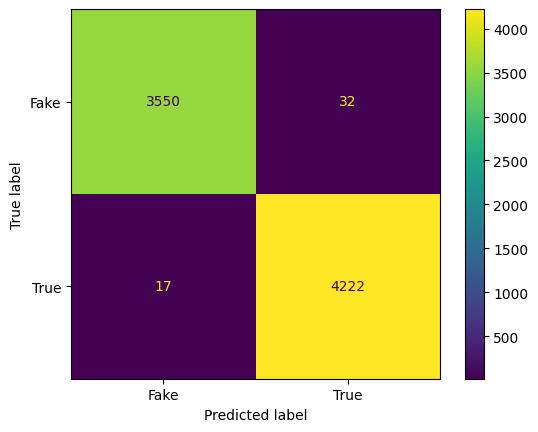

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)

disp.plot()
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

y_score = svm_model.decision_function(X_test_tfidf)

roc_auc = roc_auc_score(y_test, y_score)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.999299332762473


In [18]:
import os
import joblib

MODEL_DIR = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models"

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(svm_model, os.path.join(MODEL_DIR, "svm_model.pkl"))
joblib.dump(tfidf, os.path.join(MODEL_DIR, "svm_tfidf_vectorizer.pkl"))

print("SVM model saved successfully!")
print("TF-IDF vectorizer saved successfully!")
print("Saved location:", MODEL_DIR)

SVM model saved successfully!
TF-IDF vectorizer saved successfully!
Saved location: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models


In [19]:
loaded_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.pkl"))
loaded_tfidf = joblib.load(os.path.join(MODEL_DIR, "svm_tfidf_vectorizer.pkl"))

sample_text = X_test.iloc[0]
sample_actual = y_test.iloc[0]

sample_vector = loaded_tfidf.transform([sample_text])
sample_prediction = loaded_model.predict(sample_vector)[0]

print("Actual Label:", "True" if sample_actual == 1 else "Fake")
print("Predicted Label:", "True" if sample_prediction == 1 else "Fake")
print("Model verification successful!")

Actual Label: Fake
Predicted Label: Fake
Model verification successful!


In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "True"]
))

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3582
        True       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



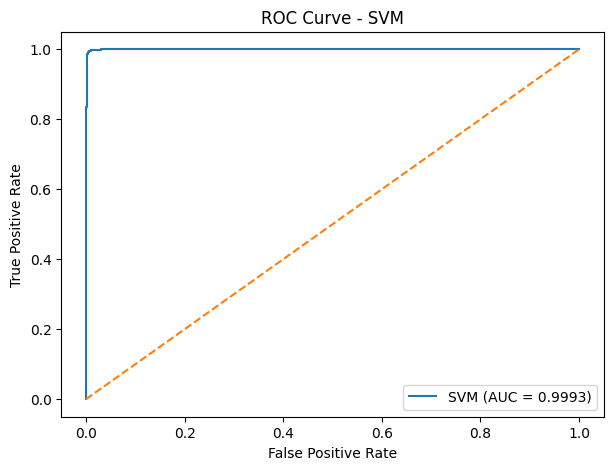

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [22]:
results = {
    "Model": "Linear SVM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

results_df = pd.DataFrame([results])

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Linear SVM,0.993735,0.992478,0.99599,0.994231,0.999299


In [23]:
RESULTS_DIR = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

results_path = os.path.join(RESULTS_DIR, "svm_results.csv")

results_df.to_csv(results_path, index=False)

print("Results saved successfully!")
print("Saved to:", results_path)

Results saved successfully!
Saved to: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/results/svm_results.csv


In [24]:
print("Dataset shape:", news_df.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("TF-IDF features:", X_train_tfidf.shape[1])
print("Model:", type(svm_model).__name__)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Dataset shape: (39105, 8)
Training samples: 31284
Testing samples: 7821
TF-IDF features: 5000
Model: LinearSVC
Accuracy: 0.9937348165196267
Precision: 0.9924776680771039
Recall: 0.9959896201934418
F1 Score: 0.9942305427999529
ROC-AUC: 0.999299332762473
